In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
!rm -rf codebar-AI-fundamentals-pixels-banking-ML-model
!git clone https://github.com/KatieHill-Fr-Gr/codebar-AI-fundamentals-pixels-banking-ML-model.git

Cloning into 'codebar-AI-fundamentals-pixels-banking-ML-model'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 4), reused 15 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 313.11 KiB | 2.72 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [3]:
df = pd.read_csv('codebar-AI-fundamentals-pixels-banking-ML-model/data/pixels_banking_loan_repayment_capstone_dataset.csv')

In [4]:
df.head()

,customer_id,age,region,account_type,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,has_credit_card,...,missed_payments_6m,support_rating,contract_type,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
0,PBG-200312,36.0,London,Premium,24,2281.0,1702.0,637.0,3,Yes,...,0,5.0,Annual,16.99,49.0,7500,36,0.36,13.57,0
1,PBG-200958,47.0,South East,Premium,13,4747.0,3045.0,655.0,1,Yes,...,0,NaN,Monthly,16.99,74.0,5000,12,0.14,6.73,1
2,PBG-200402,44.0,West Midlands,Premium,41,5605.0,5230.0,583.0,2,Yes,...,0,2.0,No fixed term,16.99,100.0,3000,48,0.32,12.42,1
3,PBG-200626,49.0,West Midlands,Premium,23,5576.0,7223.0,850.0,3,Yes,...,1,4.0,Monthly,16.99,86.0,15000,48,0.03,3.90,1
4,PBG-200272,32.0,North East,Everyday,63,4737.0,4982.0,691.0,1,No,...,3,4.0,No fixed term,0.00,77.0,10000,12,0.45,7.87,0


In [5]:
df.shape

(1200, 23)

In [6]:
df.columns

Index(['customer_id', 'age', 'region', 'account_type', 'tenure_months',
       'monthly_income', 'avg_monthly_balance', 'credit_score', 'num_products',
       'has_credit_card', 'has_crypto_wallet', 'uses_mobile_app',
       'customer_service_calls', 'missed_payments_6m', 'support_rating',
       'contract_type', 'monthly_fees', 'digital_engagement_score',
       'loan_amount', 'loan_term_months', 'debt_to_income_ratio',
       'interest_rate', 'loan_repaid'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1176 non-null   float64
 2   region                    1187 non-null   object 
 3   account_type              1172 non-null   object 
 4   tenure_months             1200 non-null   int64  
 5   monthly_income            1164 non-null   float64
 6   avg_monthly_balance       1135 non-null   float64
 7   credit_score              1159 non-null   float64
 8   num_products              1200 non-null   int64  
 9   has_credit_card           1169 non-null   object 
 10  has_crypto_wallet         1200 non-null   object 
 11  uses_mobile_app           1175 non-null   object 
 12  customer_service_calls    1200 non-null   int64  
 13  missed_payments_6m        1200 non-null   int64  
 14  support_

In [8]:
df.describe()

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
count,1176.000000,1200.000000,1164.000000,1135.000000,1159.000000,1200.000000,1200.000000,1200.000000,1135.000000,1200.000000,1129.000000,1200.000000,1200.000000,1157.000000,1164.000000,1200.000000
mean,39.086735,40.431667,3514.981959,2487.744493,667.591027,2.291667,1.620833,0.500833,3.427313,5.939783,77.338353,6955.833333,31.950000,0.240519,9.061684,0.693333
std,12.233096,22.694005,1656.860759,1796.913945,74.619774,1.128860,1.292978,0.865423,1.126776,6.549736,19.430152,5973.855966,14.138036,0.121329,2.880156,0.461302
min,18.000000,3.000000,900.000000,0.000000,390.000000,1.000000,0.000000,0.000000,1.000000,0.000000,14.000000,1000.000000,12.000000,0.030000,3.900000,0.000000
25%,30.000000,23.000000,2293.250000,1216.000000,618.000000,1.000000,1.000000,0.000000,3.000000,0.000000,64.000000,3000.000000,24.000000,0.150000,6.990000,0.000000
50%,39.000000,36.000000,3163.500000,2125.000000,668.000000,2.000000,1.000000,0.000000,4.000000,7.000000,81.000000,5000.000000,36.000000,0.230000,9.030000,1.000000
75%,47.000000,53.000000,4350.000000,3349.000000,717.500000,3.000000,2.000000,1.000000,4.000000,12.000000,94.000000,10000.000000,36.000000,0.320000,11.062500,1.000000
max,78.000000,144.000000,9960.000000,11032.000000,850.000000,5.000000,8.000000,4.000000,5.000000,16.990000,100.000000,25000.000000,60.000000,0.610000,20.190000,1.000000


In [9]:
df.isna().sum()

,0
customer_id,0
age,24
region,13
account_type,28
tenure_months,0
monthly_income,36
avg_monthly_balance,65
credit_score,41
num_products,0
has_credit_card,31


In [10]:
df["loan_repaid"].value_counts()

,count
loan_repaid,
1,832
0,368


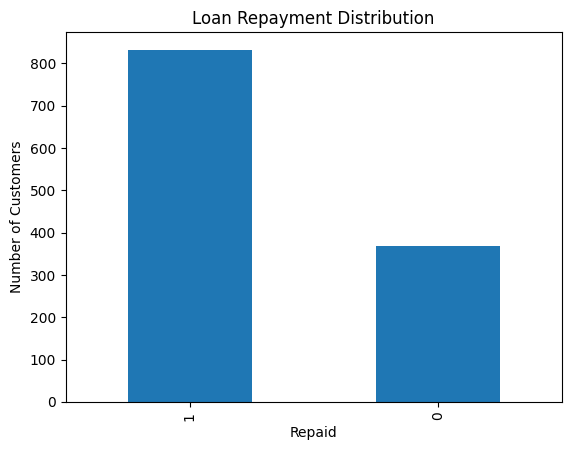

In [11]:
df["loan_repaid"].value_counts().plot(kind="bar")

plt.title("Loan Repayment Distribution")
plt.xlabel("Repaid")
plt.ylabel("Number of Customers")

plt.show()

In [12]:
df["account_type"].value_counts()

,count
account_type,
Everyday,554
Plus,305
Premium,222
Business,91


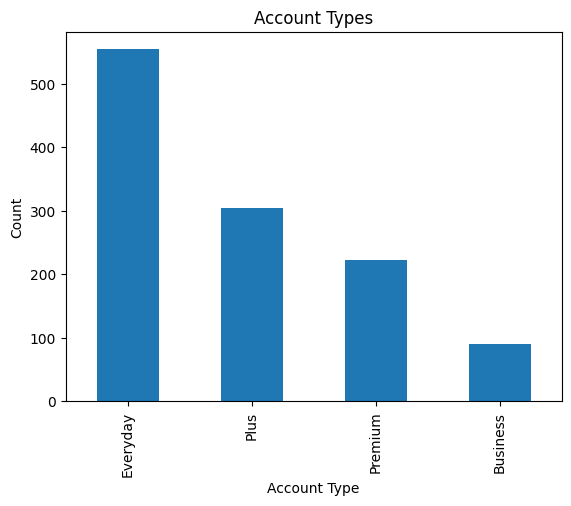

In [13]:
df["account_type"].value_counts().plot(kind="bar")

plt.title("Account Types")
plt.xlabel("Account Type")
plt.ylabel("Count")

plt.show()

Text(0, 0.5, 'Average Repayment Rate')

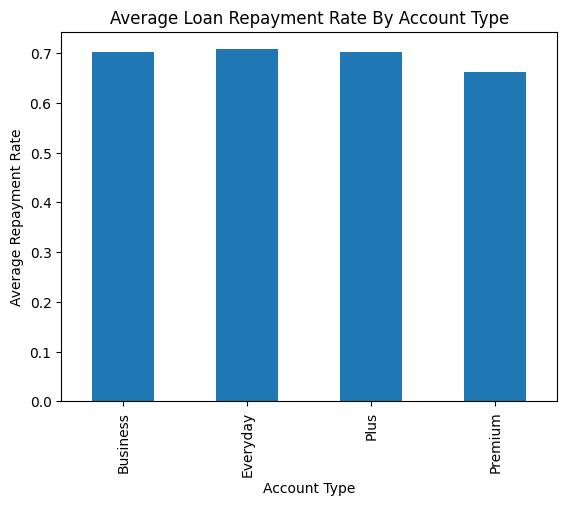

In [14]:
df.groupby("account_type")["loan_repaid"].mean().plot(kind="bar")

plt.title("Average Loan Repayment Rate By Account Type")
plt.xlabel("Account Type")
plt.ylabel("Average Repayment Rate")

In [15]:
df["missed_payments_6m"].value_counts().sort_index()

,count
missed_payments_6m,
0,816
1,238
2,86
3,49
4,11


In [16]:
df.groupby("missed_payments_6m")["loan_repaid"].mean()


,loan_repaid
missed_payments_6m,
0,0.765931
1,0.672269
2,0.348837
3,0.306122
4,0.181818


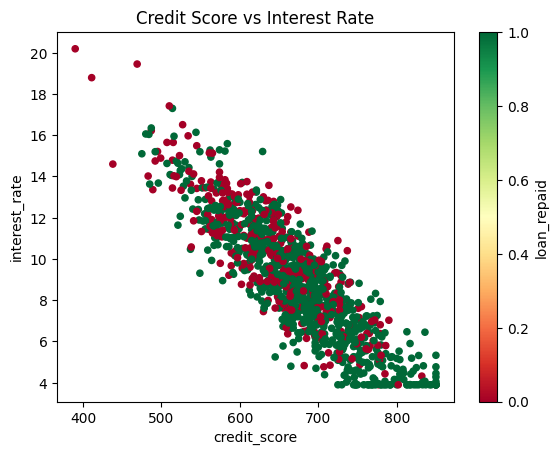

In [17]:
df.plot.scatter(
    x="credit_score",
    y="interest_rate",
    c="loan_repaid",
    colormap="RdYlGn"
)

plt.title("Credit Score vs Interest Rate")
plt.show()

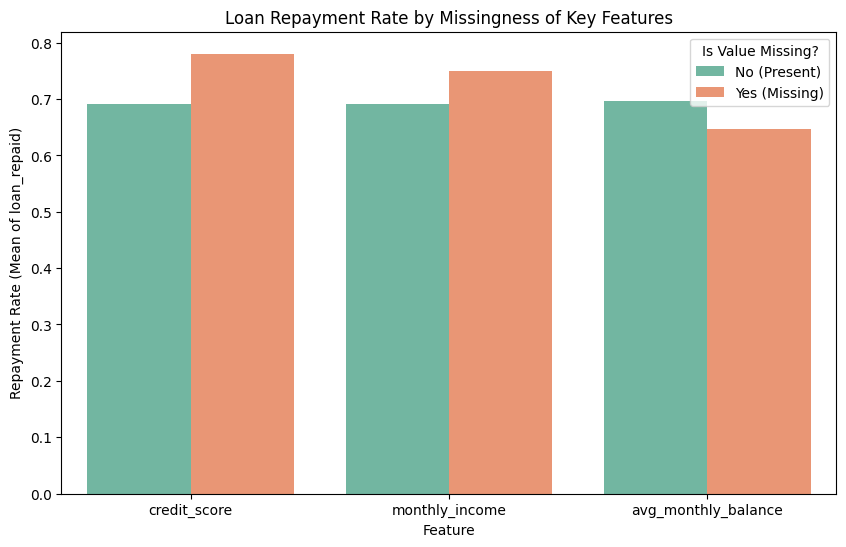

In [18]:
target_cols = ["credit_score", "monthly_income", "avg_monthly_balance"]

missing_df = df[target_cols].isna()
missing_df['loan_repaid'] = df['loan_repaid']

melted_df = missing_df.melt(
    id_vars=["loan_repaid"], var_name="Feature", value_name="Is_Missing"
)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=melted_df,
    x="Feature",
    y="loan_repaid",
    hue="Is_Missing",
    errorbar=None,
    palette="Set2",
)

plt.title("Loan Repayment Rate by Missingness of Key Features")
plt.ylabel("Repayment Rate (Mean of loan_repaid)")
plt.xlabel("Feature")
plt.legend(title="Is Value Missing?", labels=["No (Present)", "Yes (Missing)"])
plt.show()


In [19]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,digital_engagement_score,loan_amount,loan_term_months,debt_to_income_ratio,interest_rate,loan_repaid
age,1.000000,0.004554,0.046592,0.041487,0.056837,-0.001258,-0.025022,-0.013205,0.011636,0.025308,0.062130,0.051255,-0.001969,-0.010010,-0.013204,0.015121
tenure_months,0.004554,1.000000,0.019899,0.036587,-0.009169,0.012303,0.055949,0.055060,-0.048675,-0.024166,0.021666,0.018495,-0.033788,0.042095,0.003110,0.040619
monthly_income,0.046592,0.019899,1.000000,0.682567,-0.073595,0.011461,-0.004376,-0.051555,0.053603,0.059324,0.054096,0.004305,-0.037555,-0.013036,0.055764,0.087365
avg_monthly_balance,0.041487,0.036587,0.682567,1.000000,-0.025833,-0.009593,-0.011087,-0.017176,0.024549,0.055349,0.039885,-0.006147,-0.040348,-0.049522,-0.000341,0.047506
credit_score,0.056837,-0.009169,-0.073595,-0.025833,1.000000,0.011728,0.000225,0.003253,-0.001804,0.022057,0.038890,0.037392,0.046090,-0.020987,-0.874725,0.236844
num_products,-0.001258,0.012303,0.011461,-0.009593,0.011728,1.000000,0.039261,-0.001103,-0.044038,-0.009416,0.007726,0.017866,-0.025005,0.018958,-0.004803,0.029363
customer_service_calls,-0.025022,0.055949,-0.004376,-0.011087,0.000225,0.039261,1.000000,0.002146,0.000277,-0.036987,-0.036521,0.008736,-0.003045,0.026740,0.005708,-0.023119
missed_payments_6m,-0.013205,0.055060,-0.051555,-0.017176,0.003253,-0.001103,0.002146,1.000000,-0.044480,0.029275,-0.016243,-0.000396,0.028497,0.245150,0.059547,-0.300195
support_rating,0.011636,-0.048675,0.053603,0.024549,-0.001804,-0.044038,0.000277,-0.044480,1.000000,0.031021,0.068928,-0.037577,0.042722,-0.004984,0.025682,0.025941
monthly_fees,0.025308,-0.024166,0.059324,0.055349,0.022057,-0.009416,-0.036987,0.029275,0.031021,1.000000,0.036431,-0.023227,0.043474,0.023243,-0.013281,-0.025506


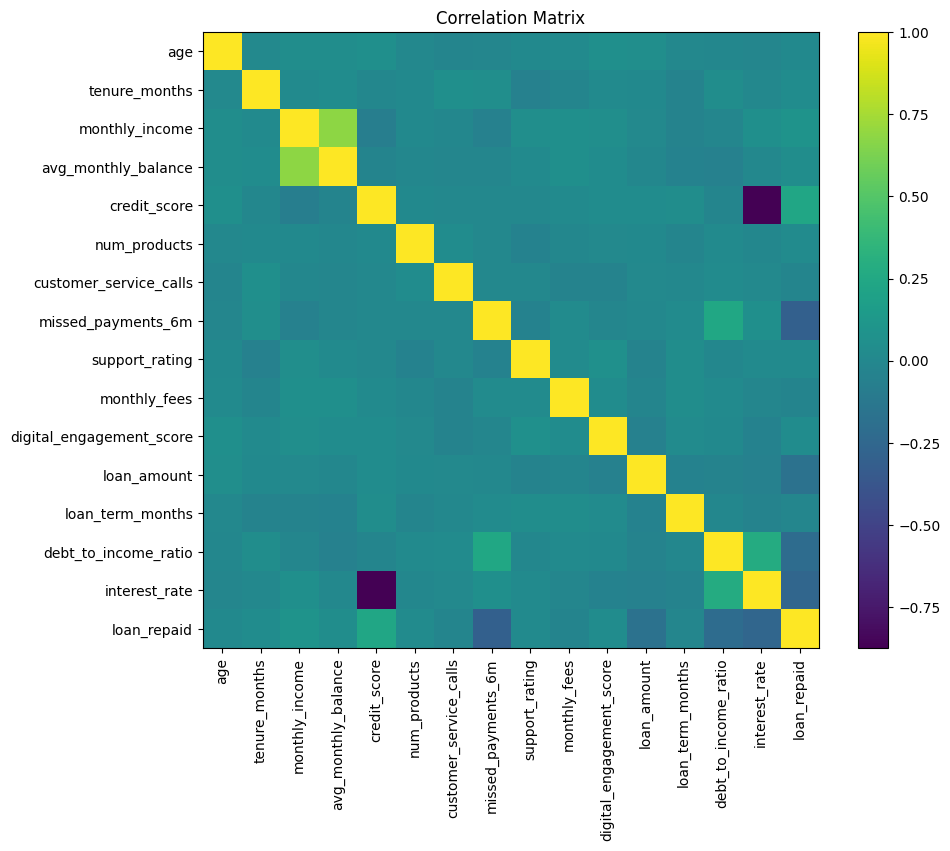

In [20]:
plt.figure(figsize=(10,8))

plt.imshow(numeric_df.corr())

plt.colorbar()

plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.title("Correlation Matrix")

plt.show()